In [1]:
import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)

import hddm
import kabuki
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
import xarray as xr

print("The current version of kabuki is: ", kabuki.__version__)
print("The current version of HDDM is: ", hddm.__version__)
print("The current version of arviz is: ", az.__version__)

The current version of kabuki is:  0.6.5RC4
The current version of HDDM is:  1.0.1RC
The current version of arviz is:  1.1.0


In [2]:
data = hddm.load_csv(hddm.__path__[0] + "/examples/cavanagh_theta_nn.csv")
data = data[data['subj_idx'].isin([0,1,2,3,4])]
data.head()

,subj_idx,stim,rt,response,theta,dbs,conf
0,0,LL,1.21,1.0,0.656275,1,HC
1,0,WL,1.63,1.0,-0.327889,1,LC
2,0,WW,1.03,1.0,-0.480285,1,HC
3,0,WL,2.77,1.0,1.927427,1,LC
4,0,WW,1.14,0.0,-0.213236,1,HC


In [3]:
%time
model_reg = hddm.HDDMRegressor(data, "v ~ 1 + C(conf, Treatment('LC'))",include = ['v', 'a', 't', 'z'])
# note: setting save_name argument will delete the _temp*.db file
save_name = "test/hddmregressor_example"
model_reg_infdata = model_reg.sample(
    500, chains = 4, 
    return_infdata = True, save_name = save_name, 
    sample_prior = True, loglike = False, ppc = True)

CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 8.34 μs
No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2540: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2540: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2540: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)


/opt/conda/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2540: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)


hddm sampling elpased time:  46.058 s
Start converting to InferenceData...


Start generating posterior prediction...
[                  1%                  ] 5 of 500 complete in 0.6 sec
[                  2%                  ] 10 of 500 complete in 1.1 sec
[-                 3%                  ] 16 of 500 complete in 1.6 sec
[-                 4%                  ] 22 of 500 complete in 2.1 sec
[--                5%                  ] 27 of 500 complete in 2.7 sec
[--                6%                  ] 33 of 500 complete in 3.2 sec
[--                7%                  ] 39 of 500 complete in 3.8 sec
[---               9%                  ] 45 of 500 complete in 4.3 sec
[---              10%                  ] 51 of 500 complete in 4.9 sec
[----             11%                  ] 57 of 500 complete in 5.5 sec
[----             12%                  ] 63 of 500 complete in 6.0 sec
[-----            13%                  ] 69 of 500 complete in 6.6 sec
[-----            15%                  ] 75 of 500 complete in 7.1 sec
[------           16%                

The time of generating PPC took 48.684 seconds


In [4]:
model_reg_infdata

<xarray.DataTree>
Group: /
├── Group: /observed_data
│       Dimensions:   (obs_id: 1427)
│       Coordinates:
│         * obs_id    (obs_id) int64 11kB 0 1 2 3 4 5 ... 1421 1422 1423 1424 1425 1426
│           subj_idx  (obs_id) int64 11kB 0 0 0 0 0 0 0 0 0 0 0 ... 4 4 4 4 4 4 4 4 4 4
│           trial     (obs_id) int64 11kB 0 1 2 3 4 5 6 ... 276 277 278 279 280 281 282
│       Data variables:
│           index     (obs_id) int64 11kB 0 1 2 3 4 5 ... 1421 1422 1423 1424 1425 1426
│           stim      (obs_id) object 11kB 'LL' 'WL' 'WW' 'WL' ... 'WW' 'WL' 'WL' 'LL'
│           rt        (obs_id) float32 6kB 1.21 1.63 1.03 2.77 ... 0.803 -0.606 0.499
│           response  (obs_id) int64 11kB 1 1 1 1 0 1 1 0 1 0 1 ... 0 0 1 1 0 1 1 1 0 1
│           theta     (obs_id) float64 11kB 0.6563 -0.3279 -0.4803 ... -0.6359 -0.2641
│           dbs       (obs_id) int64 11kB 1 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
│           conf      (obs_id) object 11kB 'HC' 'LC' 'HC' 'LC' ... 'HC' 'LC' 'LC' 'HC'
├── Group: /posterior
│       Dimensions:                           (chain: 4, draw: 500)
│       Coordinates:
│         * chain                             (chain) int64 32B 0 1 2 3
│         * draw                              (draw) int64 4kB 0 1 2 3 ... 497 498 499
│       Data variables: (12/29)
│           a                                 (chain, draw) float64 16kB 1.806 ... 1.627
│           a_std                             (chain, draw) float64 16kB 0.3813 ... 0...
│           a_subj.0                          (chain, draw) float64 16kB 2.184 ... 2.181
│           a_subj.1                          (chain, draw) float64 16kB 2.076 ... 2.136
│           a_subj.2                          (chain, draw) float64 16kB 1.558 ... 1.595
│           a_subj.3                          (chain, draw) float64 16kB 2.069 ... 2.154
│           ...                                ...
│           v_Intercept_subj.0                (chain, draw) float64 16kB 0.1519 ... 0...
│           v_Intercept_subj.1                (chain, draw) float64 16kB 0.555 ... 0....
│           v_Intercept_subj.2                (chain, draw) float64 16kB 0.9535 ... 0...
│           v_Intercept_subj.3                (chain, draw) float64 16kB 0.4092 ... 0...
│           v_Intercept_subj.4                (chain, draw) float64 16kB 1.523 ... 1.311
│           v_C(conf, Treatment('LC'))[T.HC]  (chain, draw) float64 16kB -0.2282 ... ...
├── Group: /prior
│       Dimensions:                           (chain: 1, draw: 2000)
│       Dimensions without coordinates: chain, draw
│       Data variables: (12/29)
│           a                                 (chain, draw) float64 16kB 1.292 ... 1.859
│           a_std                             (chain, draw) float64 16kB 0.2541 ... 1...
│           a_subj.0                          (chain, draw) float64 16kB 2.402 ... 1.232
│           a_subj.1                          (chain, draw) float64 16kB 1.047 ... 4.137
│           a_subj.2                          (chain, draw) float64 16kB 2.015 ... 6.517
│           a_subj.3                          (chain, draw) float64 16kB 0.474 ... 0....
│           ...                                ...
│           v_Intercept_subj.0                (chain, draw) float64 16kB -0.224 ... -...
│           v_Intercept_subj.1                (chain, draw) float64 16kB 0.2147 ... 0...
│           v_Intercept_subj.2                (chain, draw) float64 16kB 0.375 ... 0....
│           v_Intercept_subj.3                (chain, draw) float64 16kB 1.26 ... -0....
│           v_Intercept_subj.4                (chain, draw) float64 16kB 0.09214 ... ...
│           v_C(conf, Treatment('LC'))[T.HC]  (chain, draw) float64 16kB 22.67 ... 5.239
└── Group: /posterior_predictive
        Dimensions:   (chain: 4, draw: 500, obs_id: 1427)
        Coordinates:
          * chain     (chain) int64 32B 0 1 2 3
          * draw      (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
          * obs_id    (obs_id) i

In [5]:
%time
save_name = "test/hddmregressor_example"
# loading the inference data is faster than loading the origin hddm class
# model_reg = hddm.load(save_name + ".hddm")
model_reg_infdata = az.from_netcdf(save_name + ".nc")

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 6.2 μs


In [6]:
def plot_rt_quantiles_corrected(infdata, quantiles=[0.1, 0.3, 0.5, 0.7, 0.9]):
    """
    Plot quantile-quantile comparison between observed and posterior predictive reaction times (RTs).
    Handles positive (correct/upper boundary) and negative (incorrect/lower boundary) RTs separately.
    
    Parameters
    ----------
    infdata : arviz.InferenceData
        InferenceData object containing observed_data and posterior_predictive groups.
    quantiles : list of float, optional
        Quantile levels to compute and plot (default: [0.1, 0.3, 0.5, 0.7, 0.9]).
    """
    
    # 1. Extract observed data
    obs_rt_all = infdata.observed_data["rt"]
    
    # 2. Extract posterior predictive data (stack chain and draw dimensions)
    pp_rt_all = infdata.posterior_predictive["rt"].stack(sample=("chain", "draw"))

    # 3. Automatically detect response type based on RT sign:
    #    RT > 0 -> Response 1 (upper boundary/correct)
    #    RT < 0 -> Response 0 (lower boundary/incorrect)
    #    Note: Using absolute values for quantile computation
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    # === Define two conditions: positive RTs and negative RTs ===
    conditions = [
        {"name": "Positive RTs (Upper Boundary)", "sign": 1},
        {"name": "Negative RTs (Lower Boundary)", "sign": -1}
    ]
    
    for i, cond in enumerate(conditions):
        ax = axes[i]
        sign = cond["sign"]
        
        # --- A. Process observed data ---
        # Filter: keep only data with the current sign
        if sign == 1:
            curr_obs = obs_rt_all.where(obs_rt_all > 0, drop=True)
        else:
            curr_obs = obs_rt_all.where(obs_rt_all < 0, drop=True)
            
        # Skip if no data (e.g., only positive responses)
        if curr_obs.size == 0:
            ax.text(0.5, 0.5, "No Data", ha='center', fontsize=12)
            ax.set_title(cond["name"])
            continue

        # Take absolute values and compute quantiles
        # [Correction] Using dim="obs_id" for observed data
        curr_obs_abs = np.abs(curr_obs)
        obs_qs = curr_obs_abs.quantile(quantiles, dim="obs_id")
        
        # --- B. Process posterior predictive data ---
        # xarray's where operation works similarly for posterior data
        if sign == 1:
            curr_pp = pp_rt_all.where(pp_rt_all > 0, drop=True)
        else:
            curr_pp = pp_rt_all.where(pp_rt_all < 0, drop=True)
            
        # Take absolute values
        curr_pp_abs = np.abs(curr_pp)
        
        # Compute quantiles
        # Note: Posterior data typically retains the 'sample' dimension
        #       and aggregates over obs_id (trial) dimension
        # [Correction] Identify the non-sample dimension name dynamically
        pp_dim_name = [d for d in curr_pp_abs.dims if d not in ["sample", "chain", "draw"]][0]
        pp_qs = curr_pp_abs.quantile(quantiles, dim=pp_dim_name)
        
        # Calculate HDI (uncertainty intervals)
        # pp_qs has shape: (n_quantiles, n_samples)
        # Compute statistics across the sample dimension (axis=1)
        pp_qs_np = pp_qs.values
        
        # Compute mean and 94% interval for each quantile
        pp_mean = np.nanmean(pp_qs_np, axis=1)
        pp_lower = np.nanpercentile(pp_qs_np, 3, axis=1)
        pp_upper = np.nanpercentile(pp_qs_np, 97, axis=1)
        
        # --- C. Plotting ---
        # Plot posterior predictive interval (fan)
        ax.fill_between(
            quantiles, pp_lower, pp_upper, 
            color='C1', alpha=0.5, label='94% Posterior PPI'
        )
        ax.plot(
            quantiles, pp_mean, 'o-', 
            color='C1', label='Posterior Mean'
        )
        
        # Plot observed data
        ax.plot(
            quantiles, obs_qs, 'x--', 
            color='k', markersize=10, label='Observed Data'
        )
        
        ax.set_title(cond["name"])
        ax.set_xlabel("Quantile")
        ax.set_xticks(quantiles)
        if i == 0: 
            ax.set_ylabel("Reaction Time (|s|)")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

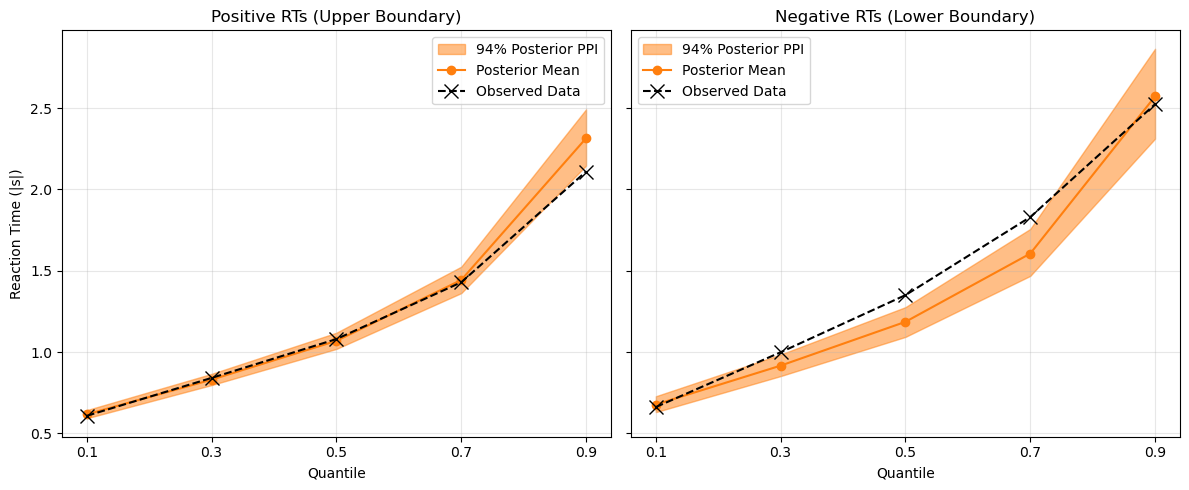

In [7]:
plot_rt_quantiles_corrected(model_reg_infdata)